# Housing Affordability Analysis

This notebook combines ACS PUMS housing records, constructs housing-cost burden measures, and maps affordability patterns across Public Use Microdata Areas (PUMAs). It then uses K-means clustering to group PUMAs with similar housing-market characteristics.

A Public Use Microdata Area (PUMA) is a Census-defined geographic unit used for releasing ACS Public Use Microdata Sample (PUMS) data. Each PUMA contains at least about 100,000 people, which makes it large enough to protect confidentiality while still allowing regional analysis. PUMAs are smaller than states but often larger than individual cities or neighborhoods. For example, a large metropolitan area may be divided into several PUMAs, while a rural PUMA may cover multiple counties.


## Load and Combine ACS Housing Files

This step reads the ACS PUMS housing files and combines them into a single household-level dataset used throughout the analysis.


In [1]:
import pandas as pd

df_a = pd.read_csv("psam_husa.csv")
df_b = pd.read_csv("psam_husb.csv")

df = pd.concat([df_a, df_b], ignore_index=True)

print(df.shape)



(1631969, 241)


## Filter to Valid Income Records

Housing burden depends on household income, so records with nonpositive income are removed before affordability measures are calculated.


In [2]:
# Keep only valid income
df = df[df["HINCP"] > 0]
print(df.shape)

(1332211, 241)


## Create Housing Cost Measures

These calculations assemble monthly and annual housing costs from the available ACS variables so the notebook can compare housing expense to income.


In [3]:
df["monthly_cost"] = df["GRNTP"].fillna(df["SMOCP"])
df["annual_cost"] = df["monthly_cost"] * 12

## Compute Housing Burden

The burden ratio is defined here as annual housing cost divided by annual household income. A value above `0.30` is commonly used to indicate housing burden, while a value above `0.50` indicates severe burden. Ratios above `1.0` mean annual housing costs exceed annual household income, which can occur for households with very low reported income.


In [4]:
df["burden_ratio"] = df["annual_cost"] / df["HINCP"]

In [5]:
df["burden_category"] = pd.cut(
    df["burden_ratio"],
    bins=[0, 0.3, 0.5, 10],
    labels=["Not burdened", "Burdened", "Severely burdened"]
)

## Aggregate to the PUMA Level

Because PUMA codes repeat across states, the analysis groups by both `STATE` and `PUMA` rather than by `PUMA` alone. The weighted average uses the ACS household weight `WGTP`, which helps the summary better represent the population rather than the raw sample counts.


In [6]:
# Weighted average burden by state and PUMA
weighted = (
    df.groupby(["STATE", "PUMA"])
    .apply(lambda x: (x["burden_ratio"] * x["WGTP"]).sum() / x["WGTP"].sum())
    .reset_index(name="avg_burden")
)


/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_81998/2328095665.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["burden_ratio"] * x["WGTP"]).sum() / x["WGTP"].sum())


In [7]:
weighted.head()

,STATE,PUMA,avg_burden
0,1,100,0.472709
1,1,200,0.324849
2,1,300,0.345751
3,1,401,0.307674
4,1,402,0.713457


## Build a National PUMA Map

This step loads the Census TIGER/Line PUMA shapefiles from the `puma_shapes` folder, combines them into one national geography layer, and merges the shapes with the affordability summary. The choropleth maps use quantile classification so the color bins contain more balanced numbers of PUMAs, which usually makes national differences easier to see.


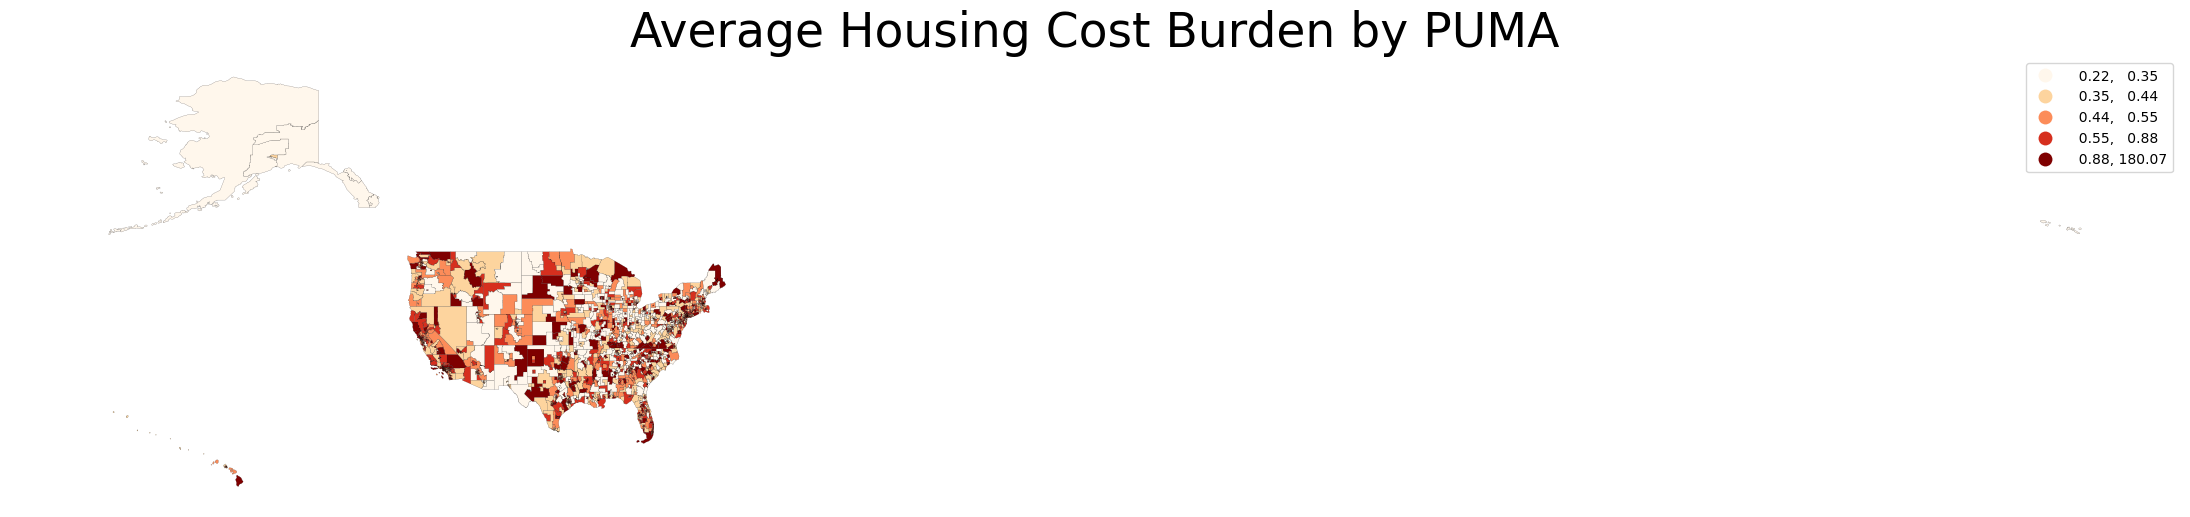

In [8]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Folder containing the extracted Census PUMA shapefile files
shapefile_dir = Path("./puma_shapes")

# Load every state-level 2023 PUMA shapefile
shape_paths = sorted(shapefile_dir.glob("tl_2023_*_puma20.shp"))

if not shape_paths:
    raise FileNotFoundError(
        f"No PUMA shapefiles found in {shapefile_dir.resolve()}. "
        "Extract files like tl_2023_06_puma20.shp into that folder."
    )

frames = [gpd.read_file(path) for path in shape_paths]
puma_shapes = gpd.GeoDataFrame(
    pd.concat(frames, ignore_index=True),
    crs=frames[0].crs,
)

# Match Census shapefile keys to ACS PUMS keys
puma_shapes["STATE"] = puma_shapes["STATEFP20"].astype(int)
puma_shapes["PUMA"] = puma_shapes["PUMACE20"].astype(int)

merged = puma_shapes.merge(weighted, on=["STATE", "PUMA"], how="inner")

ax = merged.plot(
    column="avg_burden",
    cmap="OrRd",
    legend=True,
    figsize=(28, 18),
    scheme="quantiles",
    k=5,
    edgecolor="black",
    linewidth=0.1,
)

ax.set_title("Average Housing Cost Burden by PUMA", fontsize=34)
ax.axis("off")
plt.show()


## Map Severe Housing Burden

Average burden can smooth over extreme cases, so this section maps the share of households in each PUMA that spend more than 50 percent of income on housing. The `0.50` cutoff is a common threshold for severe housing burden and highlights places where affordability stress is especially acute.


/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_81998/1904231741.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum())


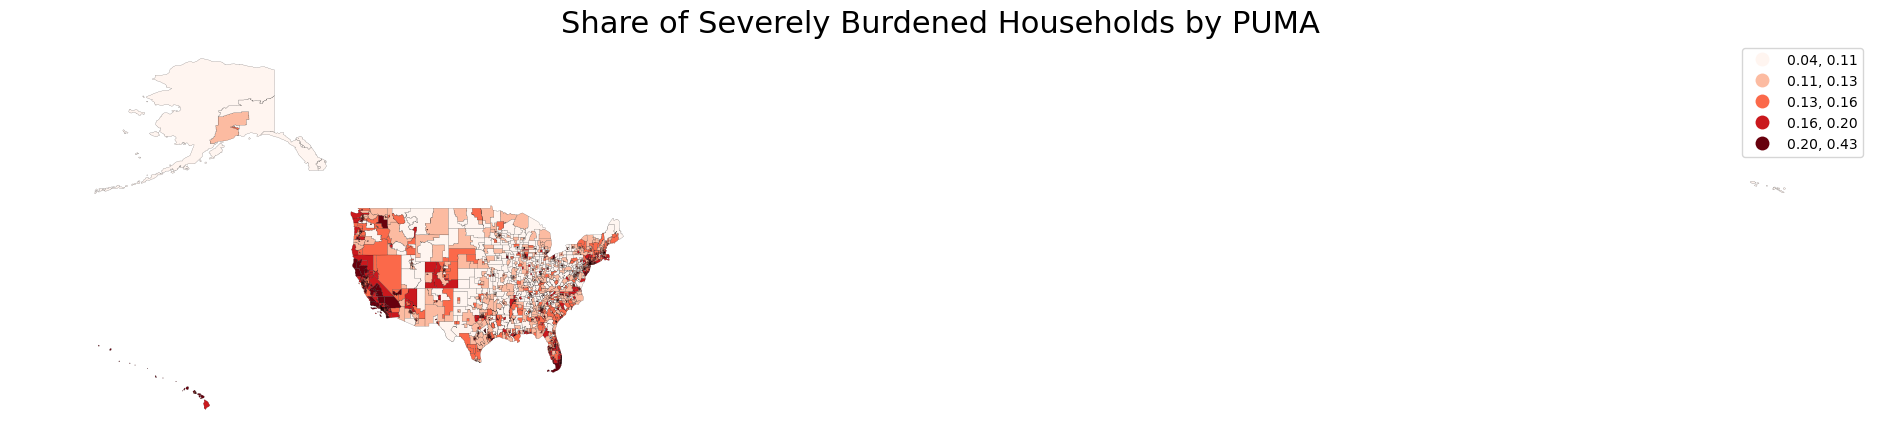

In [9]:
# Share of households with severe housing burden by PUMA
severe_burden = (
    df.assign(severely_burdened=(df["burden_ratio"] > 0.50).astype(int))
    .groupby(["STATE", "PUMA"])
    .apply(lambda x: (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum())
    .reset_index(name="severe_burden_rate")
)

severe_map = puma_shapes.merge(severe_burden, on=["STATE", "PUMA"], how="inner")

ax = severe_map.plot(
    column="severe_burden_rate",
    cmap="Reds",
    legend=True,
    figsize=(24, 16),
    scheme="quantiles",
    k=5,
    edgecolor="black",
    linewidth=0.1,
)

ax.set_title("Share of Severely Burdened Households by PUMA", fontsize=22)
ax.axis("off")
plt.show()


## Compare Renters and Owners

This section compares renters and owners using severe burden rates rather than raw average burden ratios. The ACS `TEN` variable distinguishes tenure categories; here, owner-occupied households with and without a mortgage are combined into a single `Owner` group and compared against `Renter` households.


/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_81998/1946666418.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum())
/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_81998/1946666418.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum())


  tenure_group  severe_burden_rate
0        Owner            0.102475
1       Renter            0.258852


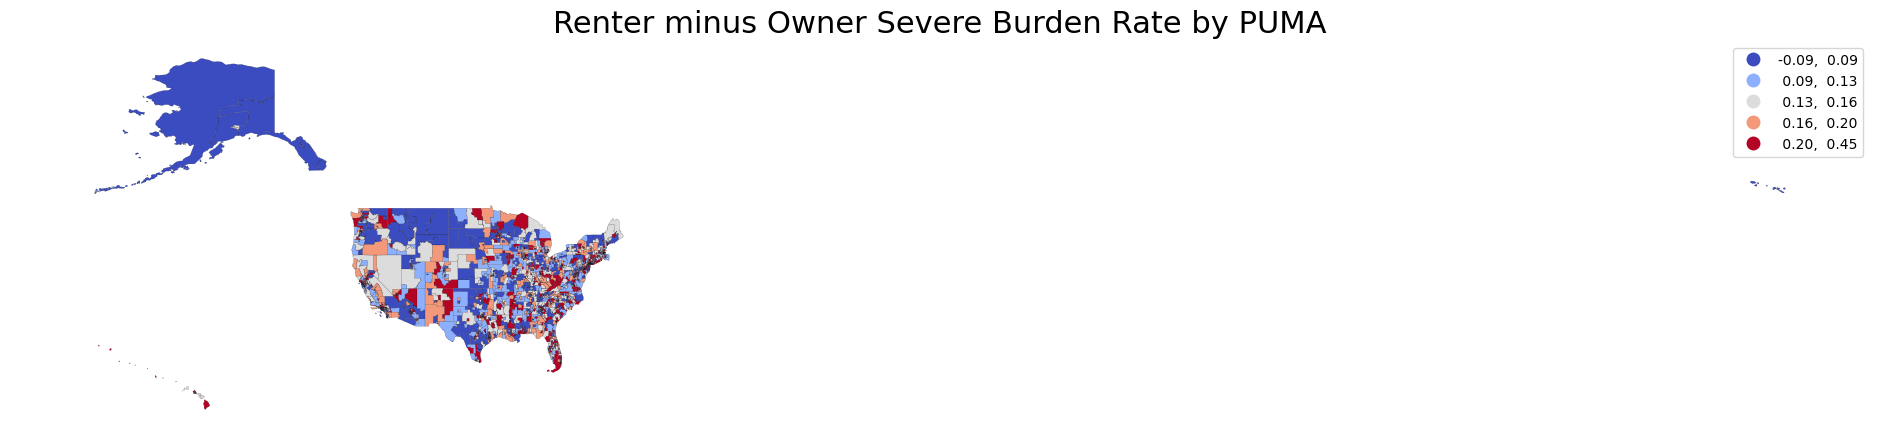

In [10]:
# Compare severe burden rates for renters and owners
tenure_labels = {1: "Owned with mortgage or loan", 2: "Owned free and clear", 3: "Rented", 4: "Occupied without payment of rent"}

tenure_severe = (
    df[df["TEN"].isin([1, 2, 3])]
    .assign(
        tenure_group=lambda x: x["TEN"].map(tenure_labels).replace({
            "Owned with mortgage or loan": "Owner",
            "Owned free and clear": "Owner",
            "Rented": "Renter"
        }),
        severely_burdened=lambda x: (x["burden_ratio"] > 0.50).astype(int)
    )
    .groupby("tenure_group")
    .apply(lambda x: (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum())
    .reset_index(name="severe_burden_rate")
)

puma_tenure_severe = (
    df[df["TEN"].isin([1, 2, 3])]
    .assign(
        tenure_group=lambda x: x["TEN"].map(tenure_labels).replace({
            "Owned with mortgage or loan": "Owner",
            "Owned free and clear": "Owner",
            "Rented": "Renter"
        }),
        severely_burdened=lambda x: (x["burden_ratio"] > 0.50).astype(int)
    )
    .groupby(["STATE", "PUMA", "tenure_group"])
    .apply(lambda x: (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum())
    .reset_index(name="severe_burden_rate")
)

print(tenure_severe)

puma_tenure_wide = puma_tenure_severe.pivot(index=["STATE", "PUMA"], columns="tenure_group", values="severe_burden_rate").reset_index()
puma_tenure_wide = puma_tenure_wide.dropna(subset=["Renter", "Owner"])
puma_tenure_wide["renter_owner_gap"] = puma_tenure_wide["Renter"] - puma_tenure_wide["Owner"]

gap_map = puma_shapes.merge(puma_tenure_wide, on=["STATE", "PUMA"], how="inner")

ax = gap_map.plot(
    column="renter_owner_gap",
    cmap="coolwarm",
    legend=True,
    figsize=(24, 16),
    scheme="quantiles",
    k=5,
    edgecolor="black",
    linewidth=0.1,
)

ax.set_title("Renter minus Owner Severe Burden Rate by PUMA", fontsize=22)
ax.axis("off")
plt.show()


## Compare Burden by Tenure

This quick check summarizes average burden by tenure category to see whether renters and owners face different housing-cost pressure.


In [11]:
df.groupby("TEN")["burden_ratio"].mean()

TEN
1.0    0.899035
2.0    0.673023
3.0    1.880204
4.0         NaN
Name: burden_ratio, dtype: float64

## Regression Modeling

The earlier sections describe where affordability stress appears. This section adds explanatory modeling by predicting both the continuous housing burden ratio and a high-burden indicator using household characteristics such as tenure, household size, building type, and region. These models do not establish causality, but they help identify which variables are most strongly associated with higher burden.


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
import numpy as np


In [16]:
# Model burden ratio and high burden using household-level predictors
reg_df = df[["burden_ratio", "TEN", "NP", "BLD", "REGION", "TYPEHUGQ", "WGTP"]].copy()
reg_df = reg_df[reg_df["burden_ratio"].notna()].copy()

# Cap extreme burden values so a few very small-income households do not dominate the linear model.
reg_df["burden_ratio_capped"] = reg_df["burden_ratio"].clip(upper=2.0)
reg_df["high_burden"] = (reg_df["burden_ratio"] > 0.30).astype(int)

feature_cols = ["TEN", "NP", "BLD", "REGION", "TYPEHUGQ"]
X = reg_df[feature_cols]
y_reg = reg_df["burden_ratio_capped"]
y_clf = reg_df["high_burden"]
weights = reg_df["WGTP"]

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test, w_train, w_test = train_test_split(
    X, y_reg, y_clf, weights, test_size=0.2, random_state=42, stratify=y_clf
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), ["TEN", "BLD", "REGION", "TYPEHUGQ"]),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), ["NP"])
    ]
)

linear_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

logit_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

linear_model.fit(X_train, y_reg_train, model__sample_weight=w_train)
reg_pred = linear_model.predict(X_test)

logit_model.fit(X_train, y_clf_train, model__sample_weight=w_train)
clf_pred = logit_model.predict(X_test)

print("Linear regression results (predicting capped burden ratio)")
print(f"RMSE: {mean_squared_error(y_reg_test, reg_pred, sample_weight=w_test) ** 0.5:.3f}")
print(f"R^2: {r2_score(y_reg_test, reg_pred, sample_weight=w_test):.3f}")
print()
print("Logistic regression results (predicting high burden > 0.30)")
print(f"Accuracy: {accuracy_score(y_clf_test, clf_pred, sample_weight=w_test):.3f}")
print(classification_report(y_clf_test, clf_pred, sample_weight=w_test, digits=3))

feature_names = linear_model.named_steps["preprocess"].get_feature_names_out()
linear_coefs = pd.Series(linear_model.named_steps["model"].coef_, index=feature_names).sort_values(key=np.abs, ascending=False)
logit_coefs = pd.Series(logit_model.named_steps["model"].coef_[0], index=feature_names).sort_values(key=np.abs, ascending=False)

print("Top linear regression coefficients (largest absolute values)")
display(linear_coefs.head(10).to_frame("coefficient"))
print("Top logistic regression coefficients (largest absolute values)")
display(logit_coefs.head(10).to_frame("coefficient"))


Linear regression results (predicting capped burden ratio)
RMSE: 0.372
R^2: 0.092

Logistic regression results (predicting high burden > 0.30)
Accuracy: 0.696
              precision    recall  f1-score   support

           0      0.734     0.864     0.794 17456963.0
           1      0.550     0.347     0.425 8367055.0

    accuracy                          0.696 25824018.0
   macro avg      0.642     0.605     0.609 25824018.0
weighted avg      0.674     0.696     0.674 25824018.0

Top linear regression coefficients (largest absolute values)


,coefficient
cat__TEN_2.0,-0.120181
cat__TEN_3.0,0.115961
cat__BLD_10.0,-0.047576
num__NP,-0.037319
cat__BLD_2.0,-0.026744
cat__REGION_2.0,-0.025724
cat__BLD_9.0,0.024854
cat__REGION_4.0,0.019268
cat__BLD_8.0,0.015900
cat__BLD_4.0,0.013446


Top logistic regression coefficients (largest absolute values)


,coefficient
cat__TEN_2.0,-0.922251
cat__TEN_3.0,0.765773
cat__REGION_2.0,-0.251712
num__NP,-0.238889
cat__BLD_2.0,-0.190566
cat__REGION_4.0,0.162980
cat__TYPEHUGQ_1.0,-0.080897
cat__TEN_1.0,0.075580
cat__BLD_4.0,0.048597
cat__BLD_1.0,0.045084


### Interpreting the Regression Results

The linear regression estimates how the selected household characteristics are associated with the capped burden ratio, while the logistic regression estimates how they are associated with the probability of being housing-burdened (`burden_ratio > 0.30`). The coefficients should be read as descriptive associations rather than causal effects. In particular, tenure, building type, and region may proxy for many underlying economic and geographic differences that are not fully observed in the model.

In these results, the linear model has relatively modest explanatory power (`R^2` around `0.09`), which suggests that the included household characteristics explain some variation in burden but leave most of it unexplained. That is not especially surprising, because housing burden is also shaped by many factors not included here, such as local wages, rents, home values, and neighborhood-specific market conditions.

The logistic regression performs better as a classification tool than the linear model does as a continuous predictor: an accuracy around `0.70` suggests the model can identify broad differences between higher- and lower-burden households, although recall for the high-burden class is much lower than recall for the non-burdened class. In other words, the model is substantially better at recognizing households that are not burdened than at catching all households that are burdened.

The largest coefficients point to tenure as the strongest observed correlate in this specification. Renter status is positively associated with both higher burden ratios and a higher probability of being burdened, while owning free and clear is strongly negatively associated with burden. Household size (`NP`) is also negatively associated with burden in these models, which may reflect the fact that larger households often combine more earners or income sources. Regional and building-type effects appear as smaller but still meaningful correlates, indicating that affordability pressure varies across parts of the country and across housing forms.


## Prepare for K-means Clustering

The clustering section imports the tools needed to standardize PUMA-level variables and assign each PUMA to a group with similar affordability characteristics.


In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


## Construct PUMA-Level Features for Clustering

K-means is run on a compact PUMA-level feature table rather than on millions of household rows. The features summarize burden, income, monthly cost, and renter share for each PUMA. Because K-means depends on the chosen variables and the selected number of clusters, the resulting groups should be interpreted as descriptive patterns rather than definitive housing-market types.


In [13]:
# Build PUMA-level features for clustering
cluster_df = (
    df.assign(is_renter=(df["TEN"] == 3).astype(int))
    .groupby(["STATE", "PUMA"])
    .agg(
        avg_burden=("burden_ratio", "mean"),
        median_income=("HINCP", "median"),
        median_monthly_cost=("monthly_cost", "median"),
        renter_share=("is_renter", "mean"),
        households=("SERIALNO", "count")
    )
    .reset_index()
)

# Trim extreme burden values so a few outliers do not dominate K-means.
cluster_df["avg_burden"] = cluster_df["avg_burden"].clip(
    lower=cluster_df["avg_burden"].quantile(0.01),
    upper=cluster_df["avg_burden"].quantile(0.99)
)

features = ["avg_burden", "median_income", "median_monthly_cost", "renter_share"]
X = cluster_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Start with 4 clusters; adjust if you want coarser or finer groupings.
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = cluster_df.groupby("cluster")[features + ["households"]].mean().round(3)
cluster_summary


,avg_burden,median_income,median_monthly_cost,renter_share,households
cluster,,,,,
0,1.081,76921.230,1621.321,0.500,443.947
1,0.629,106316.858,1807.744,0.223,501.911
2,9.275,94803.846,1645.877,0.287,540.585
3,0.593,70480.651,1019.525,0.204,606.777
4,0.726,159682.304,2658.664,0.263,515.945


## Interpreting the Cluster Summary

The `cluster_summary` table reports the average feature values for each K-means cluster. Each row represents a group of PUMAs with similar housing-market conditions, not a ranking from best to worst.

In general:

- Higher `avg_burden` suggests households in that cluster spend a larger share of income on housing.
- Higher `median_income` indicates more affluent PUMAs.
- Higher `median_monthly_cost` points to more expensive housing markets.
- Higher `renter_share` suggests a larger renter presence in the local housing stock.
- Higher `households` means the cluster contains PUMAs with larger average numbers of sampled households.

A useful next step is to compare clusters descriptively, for example identifying which cluster has high costs and high incomes versus which cluster has high burden but more moderate incomes. The numeric cluster labels themselves are arbitrary; cluster `0` is not inherently better or worse than cluster `1`.


## Map the K-means Clusters

After fitting the model, the cluster labels are joined back to the PUMA boundaries and mapped nationally. This shows which places share similar housing affordability profiles.


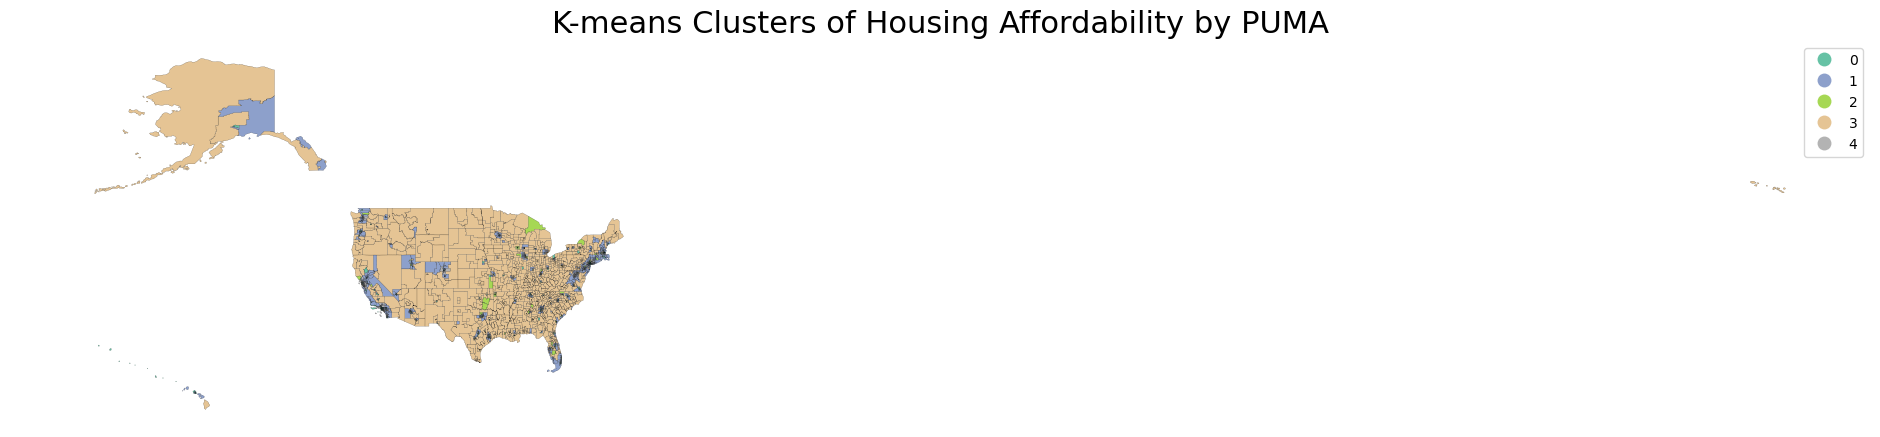

In [14]:
# Join cluster labels back to the PUMA shapes and map them
cluster_map = puma_shapes.merge(cluster_df[["STATE", "PUMA", "cluster"]], on=["STATE", "PUMA"], how="inner")

ax = cluster_map.plot(
    column="cluster",
    cmap="Set2",
    categorical=True,
    legend=True,
    figsize=(24, 16),
    edgecolor="black",
    linewidth=0.1,
)

ax.set_title("K-means Clusters of Housing Affordability by PUMA", fontsize=22)
ax.axis("off")
plt.show()


### Interpreting the Cluster Map

This map shows how the K-means model groups PUMAs with similar housing-market profiles based on average burden, median income, median monthly housing cost, and renter share. Areas with the same color do not need to be geographically close to one another; instead, they share similar combinations of affordability characteristics.

The numeric cluster labels are arbitrary, so cluster `0` is not inherently better or worse than cluster `1`. The map is most useful when read together with the `cluster_summary` table, which explains what distinguishes each group. In this result, one cluster appears across much of the country, suggesting that many PUMAs share a broadly similar affordability profile, while the smaller clusters identify more distinctive local housing-market conditions.


## Conclusion

This analysis uses ACS PUMS housing data to examine housing cost burden across U.S. PUMAs through several complementary approaches. The affordability and severe-burden maps show where housing stress is concentrated geographically, while the renter-versus-owner comparison highlights how burden can differ across tenure groups.

The K-means model adds a second layer of interpretation by grouping PUMAs with similar combinations of income, housing cost, renter share, and burden. This shows that affordability patterns are not defined by cost alone: some places combine high costs with high incomes, while others show elevated burden because housing expenses consume a larger share of more limited household resources.

The regression models extend the analysis from description to association. They suggest that tenure, household size, building type, and region are meaningfully related to housing burden, with tenure emerging as the strongest observed correlate in this specification. At the same time, the relatively modest fit of the linear model indicates that much of the variation in burden is driven by additional local economic and housing-market factors not captured here.

Taken together, the notebook shows that housing affordability is a multidimensional issue shaped by the interaction of income, costs, tenure, and local context. A natural next step would be to incorporate finer geographic controls, compare metro and nonmetro areas, or extend the analysis to policy-relevant outcomes such as severe burden among renters.
